In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

/home/nlonyuk/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv('../../cp/results_base3_enhsp.csv')
df

,config,num_trains,num_expansions,cost,makespan_pp,search_time
0,15,3,284705.0,60.0,111,240.0
1,15,4,235760.0,133.0,144,260.0
2,15,5,126013.0,186.0,183,160.0
3,15,6,234375.0,187.0,204,270.0
4,15,7,141616.0,291.0,337,230.0
...,...,...,...,...,...,...
97,12,4,313175.0,18.0,121,180.0
98,12,5,34545.0,30.0,180,20.0
99,12,6,417330.0,27.0,242,230.0
100,12,7,576215.0,33.0,256,290.0


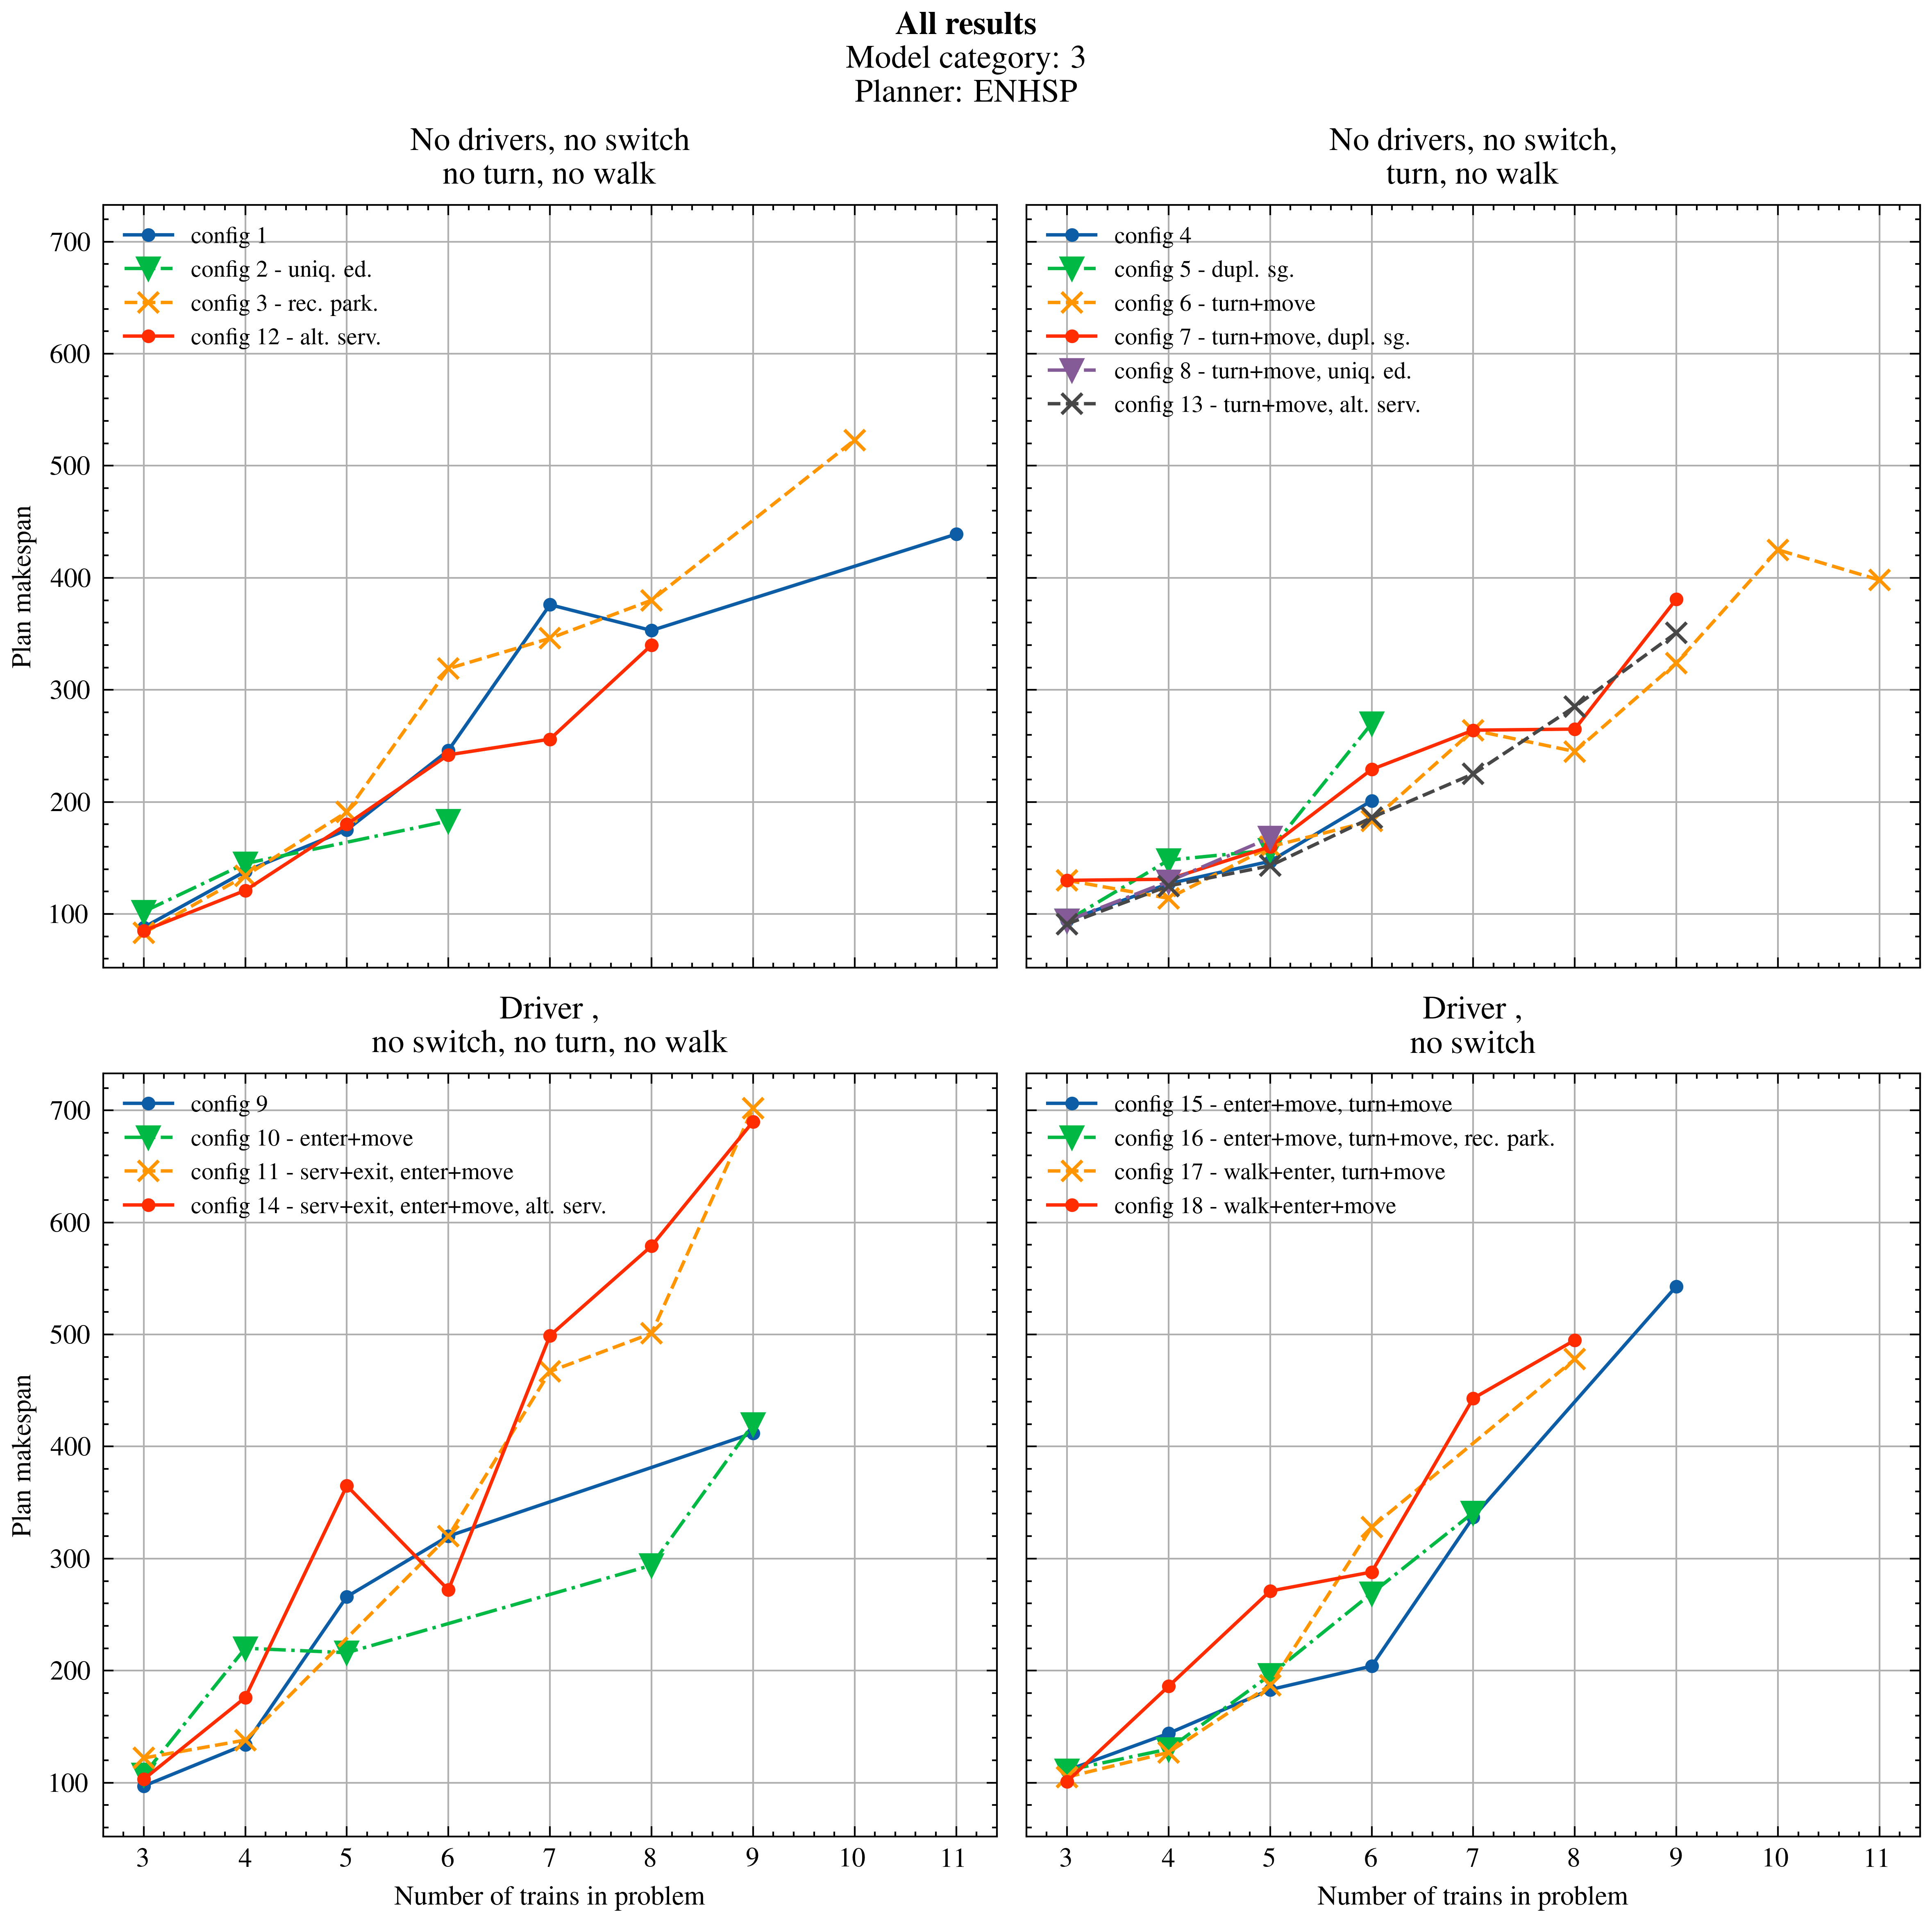

In [3]:
plt.style.use(['ieee', 'science'])

groups = [[1,2,3,12],[4,5,6,7,8,13],[9,10,11,14],[15,16,17,18]]
labels = [['', '- uniq. ed.', '- rec. park.', '- alt. serv.'],
          ['', '- dupl. sg.', '- turn+move', '- turn+move, dupl. sg.', '- turn+move, uniq. ed.', '- turn+move, alt. serv.'],
          ['', '- enter+move', '- serv+exit, enter+move', '- serv+exit, enter+move, alt. serv.'],
          ['- enter+move, turn+move', '- enter+move, turn+move, rec. park.', '- walk+enter, turn+move', '- walk+enter+move'],
          ]
group_x, group_y = [], []
for group in groups:
    x, y = [], []
    for cfg in group:
        df_filt = df.query(f"config=={cfg}")
        # df_filt = df_filt[df_filt['makespan'] > 0]
        x.append(list(df_filt['num_trains']))
        y.append(list(df_filt['makespan_pp']))
    group_x.append(x)
    group_y.append(y)

fig, ax = plt.subplots(2,2, figsize=(8,8), sharey=True, sharex=True)
ax = ax.flatten()
fig.suptitle(r"""\textbf{All results}
             Model category: 3
             Planner: ENHSP""")

for i in range(len(groups)):
    for j in range(len(group_x[i])):
        if j % 3 == 0:
            dots = '.-'
        elif j % 3 == 1:
            dots = 'v-.'
        else:
            dots = 'x--'
        ax[i].plot(group_x[i][j], group_y[i][j], dots, label=f'config {groups[i][j]} {labels[i][j]}', linewidth=1)
        ax[i].legend(loc='upper left', fontsize=7)
        ax[i].grid(True)
        # ax[i].set_xlabel('Number of trains in problem')
        ax[i].xaxis.set_major_locator(MaxNLocator(integer=True))

ax[0].set_ylabel('Plan makespan')
ax[2].set_ylabel('Plan makespan')
ax[2].set_xlabel('Number of trains in problem')
ax[3].set_xlabel('Number of trains in problem')


ax[0].set_title('No drivers, no switch\n no turn, no walk')
ax[1].set_title('No drivers, no switch,\n turn, no walk')
ax[2].set_title('Driver ,\n no switch, no turn, no walk')
ax[3].set_title('Driver ,\n no switch')


fig.tight_layout()
fig.savefig('enhsp_base3_makespans.png')


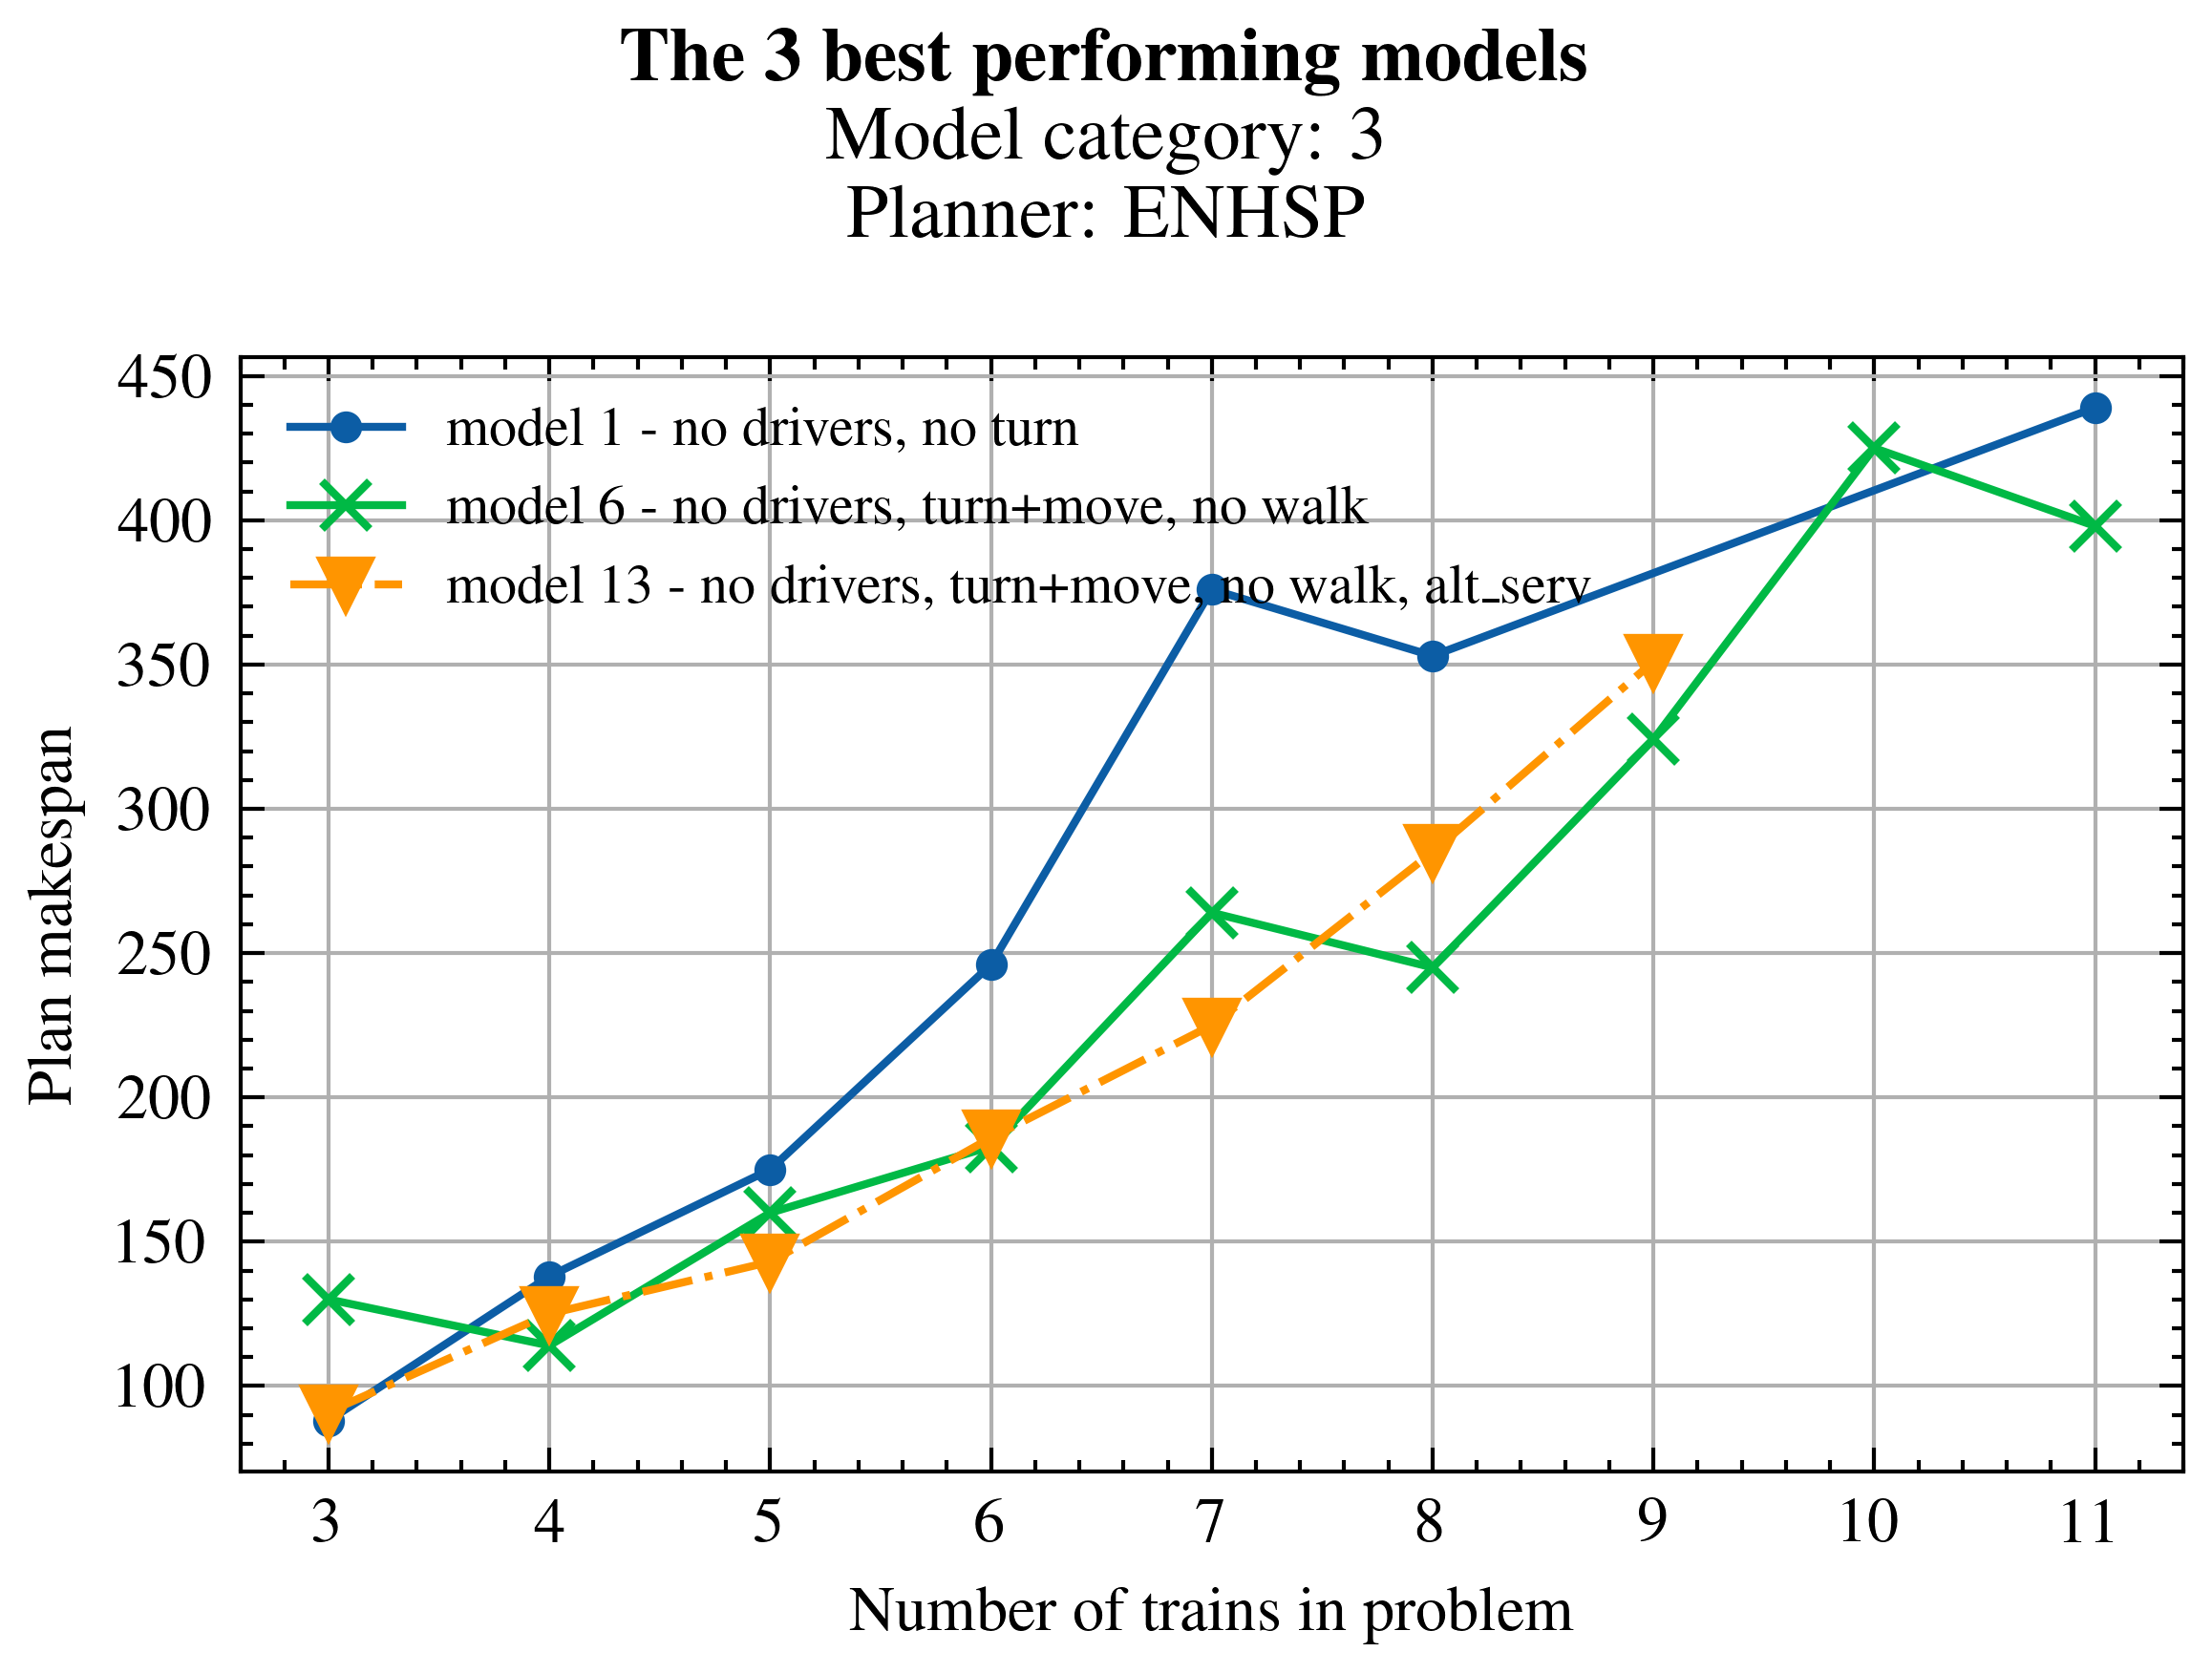

In [4]:
plt.style.use(['ieee', 'science'])

groups = [[1,6,13]]
labels = [
    ['- no drivers, no turn', '- no drivers, turn+move, no walk', '- no drivers, turn+move, no walk, alt_serv']
]

group_x, group_y = [], []
for group in groups:
    x, y = [], []
    for cfg in group:
        df_filt = df.query(f"config=={cfg}")
        # df_filt = df_filt[df_filt['makespan'] > 0]
        x.append(list(df_filt['num_trains']))
        y.append(list(df_filt['makespan_pp']))
    group_x.append(x)
    group_y.append(y)

fig, ax = plt.subplots(1,1, figsize=(4,3), sharey=True, sharex=True)
# ax = ax.flatten()
fig.suptitle(r"""\textbf{The 3 best performing models}
             Model category: 3
             Planner: ENHSP""")
configs = ['.-', 'x-', 'v-.']

for i in range(len(groups)):
    for j in range(len(group_x[i])):
        ax.plot(group_x[i][j], group_y[i][j], configs[j], label=f'model {groups[i][j]} {labels[i][j]}', linewidth=1)
        ax.legend(loc='upper left', fontsize=7)
        ax.grid(True)
        # ax[i].set_xlabel('Number of trains in problem')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylabel('Plan makespan')
ax.set_xlabel('Number of trains in problem')

fig.tight_layout()
fig.savefig('enhsp_base3_makespans_pp.png')
